# Expanded LSQ Construction

---
## Section A — Setup and Mechanical Score Base

Loads the Phase 1 output if available. If not found (e.g., fresh Colab
runtime), re-collects Baseball Savant bat-tracking data and recomputes the
Mechanical Swing Quality Score using the identical formula from Phase 1:

$$\text{MSQ}_i = 0.50 \cdot z(\text{avg_bat_speed}_i) + 0.50 \cdot z(\text{ideal_attack_angle_rate}_i)$$
$$\text{Reliability}_i = 1 - \exp(-\text{competitive_swings}_i / 100)$$
$$\widetilde{\text{MSQ}}_i = \text{MSQ}_i \times \text{Reliability}_i$$


In [26]:
!pip install pybaseball --quiet

import pandas as pd
import numpy as np
import requests
from io import StringIO
from urllib.parse import urlencode
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

EXISTING_MSQ_PATH = "dashboard_ready_swing_quality_scores.csv"  # upload to Colab if you have it


In [27]:
def load_bat_tracking(date_start="2025-03-28", date_end="2025-09-30",
                      season_start=2025, season_end=2025,
                      player_type="batter", min_swings=50, game_type="Regular"):
    base_url = "https://baseballsavant.mlb.com/leaderboard/bat-tracking/swing-path-attack-angle"
    params = {
        "dateStart": date_start, "dateEnd": date_end, "gameType": game_type,
        "minSwings": min_swings, "minGroupSwings": 1,
        "seasonStart": season_start, "seasonEnd": season_end,
        "type": player_type, "csv": "true"
    }
    url = base_url + "?" + urlencode(params)
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    text = response.text
    if "<html" in text.lower():
        raise ValueError("Response looks like HTML, not CSV. Check URL or parameters.")
    df = pd.read_csv(StringIO(text))
    df["date_start"] = date_start
    df["date_end"] = date_end
    return df


def clean_colname(c):
    return c.strip().lower().replace(" ", "_")


def normalize_player_name(name):
    if pd.isna(name):
        return name
    name = str(name)
    if "," in name:
        last, first = name.split(",", 1)
        name = f"{first.strip()} {last.strip()}"
    name = name.lower()
    name = "".join(ch for ch in name if ch.isalnum() or ch.isspace())
    return " ".join(name.split())


def recompute_mechanical_score():
    print("Existing Phase 1 output not found — recollecting bat-tracking data and recomputing MSQ...")
    bat = load_bat_tracking(min_swings=50)
    bat.columns = [clean_colname(c) for c in bat.columns]

    required_cols = ["id", "name", "avg_bat_speed", "ideal_attack_angle_rate", "competitive_swings"]
    missing = [c for c in required_cols if c not in bat.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    for col in ["avg_bat_speed", "ideal_attack_angle_rate", "competitive_swings"]:
        bat[col] = pd.to_numeric(bat[col], errors="coerce")
    bat = bat.dropna(subset=["avg_bat_speed", "ideal_attack_angle_rate", "competitive_swings"]).copy()
    bat["name_norm"] = bat["name"].apply(normalize_player_name)

    z_base = bat[bat["competitive_swings"] >= 50]
    bs_mean, bs_std = z_base["avg_bat_speed"].mean(), z_base["avg_bat_speed"].std()
    aa_mean, aa_std = z_base["ideal_attack_angle_rate"].mean(), z_base["ideal_attack_angle_rate"].std()

    bat["z_avg_bat_speed"] = (bat["avg_bat_speed"] - bs_mean) / bs_std
    bat["z_ideal_attack_angle_rate"] = (bat["ideal_attack_angle_rate"] - aa_mean) / aa_std
    bat["mechanical_swing_quality_score"] = (
        0.50 * bat["z_avg_bat_speed"] + 0.50 * bat["z_ideal_attack_angle_rate"]
    )
    bat["msq_reliability"] = 1 - np.exp(-bat["competitive_swings"] / 100)
    bat["mechanical_swing_quality_shrunk"] = (
        bat["mechanical_swing_quality_score"] * bat["msq_reliability"]
    )
    return bat


try:
    msq_df = pd.read_csv(EXISTING_MSQ_PATH)
    msq_df.columns = [clean_colname(c) for c in msq_df.columns]
    print(f"Loaded existing Mechanical Score file: {EXISTING_MSQ_PATH}  shape={msq_df.shape}")
except FileNotFoundError:
    msq_df = recompute_mechanical_score()
    print(f"Recomputed Mechanical Score.  shape={msq_df.shape}")

required = ["id", "name", "mechanical_swing_quality_shrunk", "competitive_swings"]
missing = [c for c in required if c not in msq_df.columns]
if missing:
    raise ValueError(f"msq_df is missing required columns: {missing}")

print(msq_df[required].head())


Existing Phase 1 output not found — recollecting bat-tracking data and recomputing MSQ...
Recomputed Mechanical Score.  shape=(587, 21)
       id                name  mechanical_swing_quality_shrunk  \
0  519317  Stanton, Giancarlo                         2.358629   
1  665833         Cruz, Oneil                         1.180244   
2  691406    Caminero, Junior                         1.834065   
3  656180        Adams, Riley                         0.656328   
4  691023      Walker, Jordan                         1.058226   

   competitive_swings  
0                 448  
1                 810  
2                1091  
3                 500  
4                 677  


---
## Section B — Fetch Supporting Data via PyBaseball

Two endpoints are used:

- `statcast_batter_expected_stats(2025)` → xwOBA (`est_woba`)
- `statcast_batter_exitvelo_barrels(2025)` → barrel rate (`brl_percent`),
  hard-hit rate (`ev95percent`), average exit velocity (`avg_hit_speed`)

Both are keyed on `player_id` (MLBAM ID), matching `id` in the Mechanical
Score dataframe (Section A).


In [28]:
from pybaseball import statcast_batter_expected_stats, statcast_batter_exitvelo_barrels

exp_2025 = statcast_batter_expected_stats(2025, minPA=1)
exp_2025.columns = [clean_colname(c) for c in exp_2025.columns]
print("expected_stats:", exp_2025.shape)
print(exp_2025.columns.tolist())
exp_2025.head()


expected_stats: (673, 14)
['last_name,_first_name', 'player_id', 'year', 'pa', 'bip', 'ba', 'est_ba', 'est_ba_minus_ba_diff', 'slg', 'est_slg', 'est_slg_minus_slg_diff', 'woba', 'est_woba', 'est_woba_minus_woba_diff']


,"last_name,_first_name",player_id,year,pa,bip,ba,est_ba,est_ba_minus_ba_diff,slg,est_slg,est_slg_minus_slg_diff,woba,est_woba,est_woba_minus_woba_diff
0,"Lindor, Francisco",596019,2025,732,520,0.267,0.260,0.007,0.466,0.454,0.012,0.350,0.345,0.005
1,"Devers, Rafael",646240,2025,729,419,0.252,0.244,0.008,0.479,0.487,-0.008,0.365,0.367,-0.002
2,"Ohtani, Shohei",660271,2025,727,426,0.282,0.274,0.008,0.622,0.649,-0.027,0.418,0.425,-0.007
3,"Olson, Matt",621566,2025,724,453,0.272,0.249,0.023,0.484,0.492,-0.008,0.366,0.360,0.006
4,"Schwarber, Kyle",656941,2025,724,408,0.240,0.249,-0.009,0.563,0.581,-0.018,0.391,0.401,-0.010


In [29]:
ev_2025 = statcast_batter_exitvelo_barrels(2025, minBBE=1)
ev_2025.columns = [clean_colname(c) for c in ev_2025.columns]
print("exitvelo_barrels:", ev_2025.shape)
print(ev_2025.columns.tolist())
ev_2025.head()


exitvelo_barrels: (666, 18)
['last_name,_first_name', 'player_id', 'attempts', 'avg_hit_angle', 'anglesweetspotpercent', 'max_hit_speed', 'avg_hit_speed', 'ev50', 'fbld', 'gb', 'max_distance', 'avg_distance', 'avg_hr_distance', 'ev95plus', 'ev95percent', 'barrels', 'brl_percent', 'brl_pa']


,"last_name,_first_name",player_id,attempts,avg_hit_angle,anglesweetspotpercent,max_hit_speed,avg_hit_speed,ev50,fbld,gb,max_distance,avg_distance,avg_hr_distance,ev95plus,ev95percent,barrels,brl_percent,brl_pa
0,"Arraez, Luis",650333,618,12.2,36.9,107.8,86.1,93.6,87.6,85.1,402.0,152.0,370.0,103,16.7,7,1.1,1.0
1,"Kwan, Steven",680757,575,15.6,39.3,104.2,86.2,94.4,87.8,85.1,431.0,167.0,381.0,111,19.3,11,1.9,1.6
2,"Hoerner, Nico",663538,554,12.5,36.1,108.1,86.7,96.7,89.3,85.8,412.0,155.0,379.0,168,30.3,13,2.3,2.0
3,"Perdomo, Geraldo",672695,533,15.5,36.0,108.2,87.6,97.4,90.3,86.6,423.0,165.0,393.0,170,31.9,33,6.2,4.6
4,"Betts, Mookie",605141,531,18.0,37.7,108.4,89.1,98.1,91.6,86.0,412.0,191.0,390.0,190,35.8,29,5.5,4.4


---
## Section C — Join on MLBAM Player ID + Match-Rate Validation

Target: **≥ 90% match rate** for each join (per Phase 1 milestone plan,
Section 15.3). Unmatched players and post-join missingness are reported
explicitly — this is not silently dropped.


In [30]:
def validate_join(left, right, right_key_candidates, value_cols, label):
    right = right.copy()
    rk = next((c for c in right_key_candidates if c in right.columns), None)
    if rk is None:
        print(f"[{label}] join key not found in right dataset (looked for {right_key_candidates}). Skipping join.")
        return left

    right["_jid"] = pd.to_numeric(right[rk], errors="coerce")
    left = left.copy()
    left["_jid"] = pd.to_numeric(left["id"], errors="coerce")

    keep_cols = ["_jid"] + [c for c in value_cols if c in right.columns]
    before = len(left)
    merged = left.merge(right[keep_cols], on="_jid", how="left", suffixes=("", "_r"))

    matched = merged[value_cols[0]].notna().sum() if value_cols[0] in merged.columns else 0
    match_rate = matched / before * 100
    print(f"[{label}] matched {matched}/{before} ({match_rate:.1f}%)")
    if match_rate < 90:
        print(f"  WARNING: match rate below 90% target for {label}.")

    unmatched = merged[merged[value_cols[0]].isna()][["id", "name"]] if value_cols[0] in merged.columns else pd.DataFrame()
    if len(unmatched) > 0:
        print(f"  {len(unmatched)} unmatched players (showing up to 5): {unmatched['name'].head(5).tolist()}")

    return merged.drop(columns=["_jid"])


working_df = msq_df.copy()

working_df = validate_join(
    working_df, exp_2025,
    right_key_candidates=["player_id", "playerid", "mlbam_id", "batter"],
    value_cols=["est_woba"],
    label="expected_stats (xwOBA)"
)

working_df = validate_join(
    working_df, ev_2025,
    right_key_candidates=["player_id", "playerid", "mlbam_id", "batter"],
    value_cols=["brl_percent", "ev95percent", "avg_hit_speed"],
    label="exitvelo_barrels (barrel% / hard-hit% / EV)"
)

working_df = working_df.rename(columns={
    "est_woba": "xwoba",
    "brl_percent": "barrel_rate",
    "ev95percent": "hard_hit_rate",
    "avg_hit_speed": "avg_exit_velocity"
})

print("\nWorking dataframe shape after all joins:", working_df.shape)
working_df.head()


[expected_stats (xwOBA)] matched 587/587 (100.0%)
[exitvelo_barrels (barrel% / hard-hit% / EV)] matched 587/587 (100.0%)

Working dataframe shape after all joins: (587, 25)


,id,name,side,avg_bat_speed,swing_tilt,attack_angle,attack_direction,ideal_attack_angle_rate,avg_intercept_y_vs_plate,avg_intercept_y_vs_batter,...,name_norm,z_avg_bat_speed,z_ideal_attack_angle_rate,mechanical_swing_quality_score,msq_reliability,mechanical_swing_quality_shrunk,xwoba,barrel_rate,hard_hit_rate,avg_exit_velocity
0,519317,"Stanton, Giancarlo",R,80.620201,27.928918,10.465512,-4.249249,0.620536,-0.987857,25.850922,...,giancarlo stanton,3.438863,1.332470,2.385666,0.988667,2.358629,0.354,22.1,55.2,94.4
1,665833,"Cruz, Oneil",L,78.773176,33.444853,9.163125,-7.280278,0.476543,7.493759,35.340266,...,oneil cruz,2.740794,-0.379590,1.180602,0.999696,1.180244,0.324,17.9,56.6,95.8
2,691406,"Caminero, Junior",R,78.537770,26.211024,7.998660,-5.322044,0.593951,7.691021,35.927821,...,junior caminero,2.651824,1.016374,1.834099,0.999982,1.834065,0.346,14.0,51.4,92.4
3,656180,"Adams, Riley",R,78.304560,34.636063,8.452584,-1.026635,0.404000,2.113821,30.644403,...,riley adams,2.563684,-1.242123,0.660781,0.993262,0.656328,0.275,10.5,52.3,91.8
4,691023,"Walker, Jordan",R,78.067880,31.399075,6.198435,-5.356972,0.478582,6.332488,30.063923,...,jordan walker,2.474233,-0.355349,1.059442,0.998852,1.058226,0.278,10.9,50.0,92.3


---
## Section D — Expanded LSQ Construction

$$
\hat{Q}_i^{\text{expanded}} =
  0.40 \cdot z(\widetilde{\text{MSQ}}_i)
+ 0.25 \cdot z(\text{xwOBA}_i)
+ 0.15 \cdot z(\text{barrel\_rate}_i)
+ 0.10 \cdot z(\text{hard\_hit\_rate}_i)
+ 0.10 \cdot z(\text{avg\_exit\_velocity}_i)
$$



In [31]:
EXPANDED_COLS = ["mechanical_swing_quality_shrunk", "xwoba", "barrel_rate",
                 "hard_hit_rate", "avg_exit_velocity"]

for col in EXPANDED_COLS:
    if col not in working_df.columns:
        working_df[col] = np.nan

working_df["expanded_lsq_available"] = working_df[EXPANDED_COLS].notna().all(axis=1)

n_available = working_df["expanded_lsq_available"].sum()
n_total = len(working_df)
print(f"Players with all Expanded LSQ components available: {n_available}/{n_total} "
      f"({n_available/n_total*100:.1f}%)")

def zscore(s):
    return (s - s.mean()) / s.std()

z_cols = {}
for col in EXPANDED_COLS:
    z_cols[f"z_{col}"] = zscore(working_df.loc[working_df["expanded_lsq_available"], col])

for zc, vals in z_cols.items():
    working_df[zc] = np.nan
    working_df.loc[working_df["expanded_lsq_available"], zc] = vals

WEIGHTS = {
    "mechanical_swing_quality_shrunk": 0.40,
    "xwoba": 0.25,
    "barrel_rate": 0.15,
    "hard_hit_rate": 0.10,
    "avg_exit_velocity": 0.10,
}

working_df["expanded_latent_swing_quality_shrunk"] = np.nan
mask = working_df["expanded_lsq_available"]
working_df.loc[mask, "expanded_latent_swing_quality_shrunk"] = sum(
    WEIGHTS[col] * working_df.loc[mask, f"z_{col}"] for col in EXPANDED_COLS
)

working_df["expanded_latent_swing_quality_shrunk_percentile"] = (
    working_df["expanded_latent_swing_quality_shrunk"].rank(pct=True) * 100
)

# Dashboard fallback: Expanded LSQ when available, else Mechanical Score
working_df["dashboard_ranking_score"] = working_df["expanded_latent_swing_quality_shrunk"].fillna(
    working_df["mechanical_swing_quality_shrunk"]
)

print(working_df[["id", "name", "mechanical_swing_quality_shrunk",
                   "expanded_latent_swing_quality_shrunk", "dashboard_ranking_score"]].head(10))


Players with all Expanded LSQ components available: 587/587 (100.0%)
       id                  name  mechanical_swing_quality_shrunk  \
0  519317    Stanton, Giancarlo                         2.358629   
1  665833           Cruz, Oneil                         1.180244   
2  691406      Caminero, Junior                         1.834065   
3  656180          Adams, Riley                         0.656328   
4  691023        Walker, Jordan                         1.058226   
5  678877       Noel, Jhonkensy                         0.711200   
6  666176             Adell, Jo                         1.065755   
7  695506       Caglianone, Jac                         1.011592   
8  656941       Schwarber, Kyle                         1.889758   
9  671286  Rodríguez, Johnathan                        -0.138661   

   expanded_latent_swing_quality_shrunk  dashboard_ranking_score  
0                              2.595950                 2.595950  
1                              1.648463         

---
## Section E — Output Files and Summary


In [32]:
expanded_output_path = OUTPUT_DIR / "expanded_latent_swing_quality_scores.csv"
working_df.to_csv(expanded_output_path, index=False)

main_ranking_df = working_df[working_df["competitive_swings"] >= 100].copy()
main_ranking_df = main_ranking_df.sort_values("dashboard_ranking_score", ascending=False)
main_ranking_output_path = OUTPUT_DIR / "main_ranking_expanded_lsq_min_100_swings.csv"
main_ranking_df.to_csv(main_ranking_output_path, index=False)

print("Files saved:")
print(f"  1. {expanded_output_path}")
print(f"  2. {main_ranking_output_path}")

print(f"Total players: {n_total}")
print(f"Expanded LSQ computed for: {n_available} ({n_available/n_total*100:.1f}%)")
print(f"Fallback to Mechanical Score only: {n_total - n_available}")
print("\nTop 10 by dashboard_ranking_score (competitive_swings >= 100):")
print(main_ranking_df[["name", "dashboard_ranking_score", "expanded_latent_swing_quality_shrunk",
                        "mechanical_swing_quality_shrunk"]].head(10))


Files saved:
  1. outputs/expanded_latent_swing_quality_scores.csv
  2. outputs/main_ranking_expanded_lsq_min_100_swings.csv
Total players: 587
Expanded LSQ computed for: 587 (100.0%)
Fallback to Mechanical Score only: 0

Top 10 by dashboard_ranking_score (competitive_swings >= 100):
                   name  dashboard_ranking_score  \
0    Stanton, Giancarlo                 2.595950   
8       Schwarber, Kyle                 2.577953   
12         Judge, Aaron                 2.536680   
30       Ohtani, Shohei                 2.255975   
123          Soto, Juan                 2.203610   
41         Alonso, Pete                 1.939009   
61      Carroll, Corbin                 1.859053   
2      Caminero, Junior                 1.848098   
52       Jensen, Carter                 1.749980   
17    Acuña Jr., Ronald                 1.660747   

     expanded_latent_swing_quality_shrunk  mechanical_swing_quality_shrunk  
0                                2.595950                        

---
## Section F — RQ1 Figures: Bat-Tracking Components vs. Contact-Quality Outcomes

Uses the **core dataset** (`competitive_swings >= 100`, n = 512) rather than
the full 587, for consistency with the reliability-shrinkage threshold used
throughout this project. Note: correlations differ slightly from the full
sample — in particular, `ideal_attack_angle_rate` vs `xwoba` is **not
significant** on the core dataset (p > .05), despite being marginally
significant on the full 587.

> **Caution:** `expanded_latent_swing_quality_shrunk` is *not* correlated
> against `xwoba` here, because xwOBA is already a 25%-weighted input to
> Expanded LSQ — that correlation would be circular and is excluded from
> RQ1 validation.


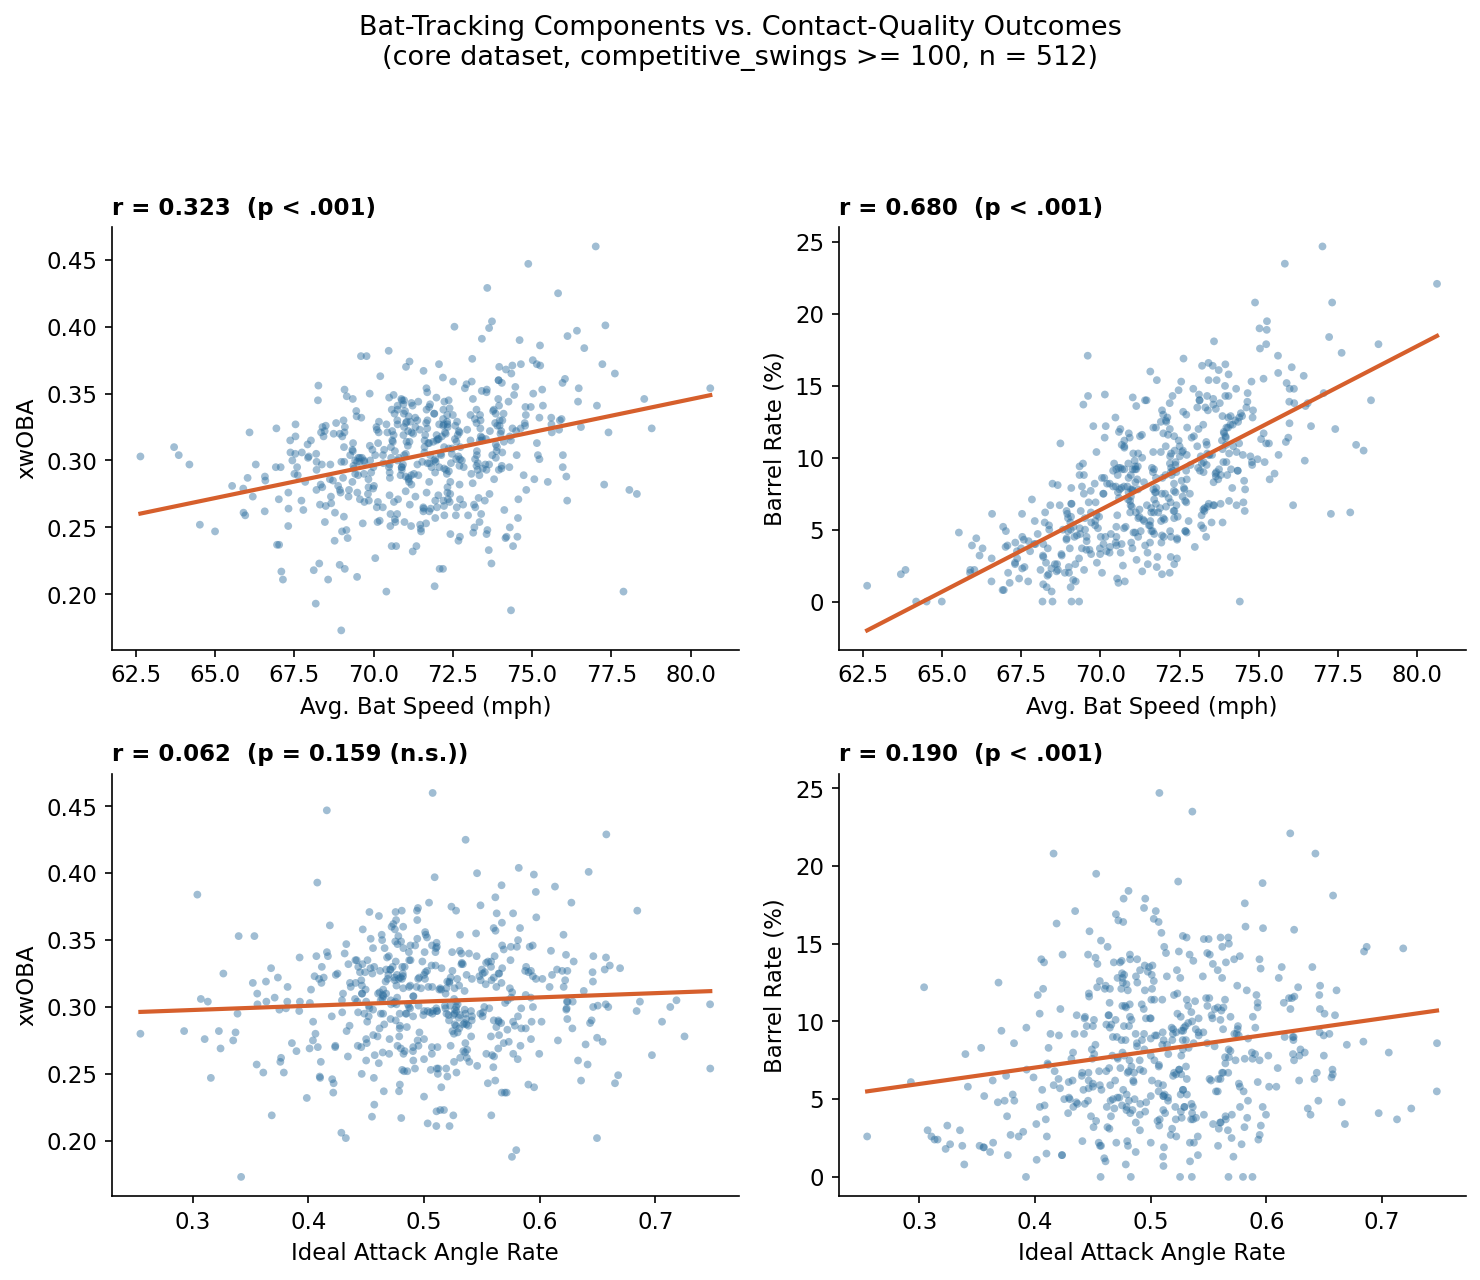

In [33]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

mpl.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "figure.dpi": 150, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
})

core_df = main_ranking_df  # competitive_swings >= 100, n = 512

pairs = [
    ("avg_bat_speed", "xwoba", "Avg. Bat Speed (mph)", "xwOBA"),
    ("avg_bat_speed", "barrel_rate", "Avg. Bat Speed (mph)", "Barrel Rate (%)"),
    ("ideal_attack_angle_rate", "xwoba", "Ideal Attack Angle Rate", "xwOBA"),
    ("ideal_attack_angle_rate", "barrel_rate", "Ideal Attack Angle Rate", "Barrel Rate (%)"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8.5))
axes = axes.flatten()
for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, pairs):
    sub = core_df[[xcol, ycol]].dropna()
    r, p = stats.pearsonr(sub[xcol], sub[ycol])
    sig = "p < .001" if p < 0.001 else f"p = {p:.3f}" + ("" if p < 0.05 else " (n.s.)")
    ax.scatter(sub[xcol], sub[ycol], s=14, alpha=0.45, color="#2C6E9E", edgecolors="none")
    import numpy as np
    z = np.polyfit(sub[xcol], sub[ycol], 1)
    xs = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
    ax.plot(xs, np.polyval(z, xs), color="#D65F2C", linewidth=2)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(f"r = {r:.3f}  ({sig})", loc="left", fontsize=11, fontweight="bold")

fig.suptitle("Bat-Tracking Components vs. Contact-Quality Outcomes\n"
              "(core dataset, competitive_swings >= 100, n = 512)", fontsize=13, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(OUTPUT_DIR / "figure_11_rq1_scatter_grid.png", bbox_inches="tight")
plt.show()


---
## Section G — Full Correlation Matrix, Multicollinearity Diagnostics, and Circular-Correlation Check

This section reproduces every quantitative claim cited in Section 5.1 of the
MRP that is *not* covered by Section F's scatter plots:

1. **Figure 12** — full correlation matrix (3 components x 4 outcomes)
2. **Multicollinearity diagnostic** — `hard_hit_rate` vs `avg_exit_velocity`
3. **Circular-correlation check** — `expanded_latent_swing_quality_shrunk` vs
   `xwoba` is computed and printed, but explicitly flagged as **excluded**
   from RQ1 evidence (xwOBA is a 25%-weighted input to Expanded LSQ)
4. **Full (n=587) vs core (n=512) comparison** — shows why
   `ideal_attack_angle_rate` vs `xwoba` flips from marginally significant to
   non-significant depending on sample choice


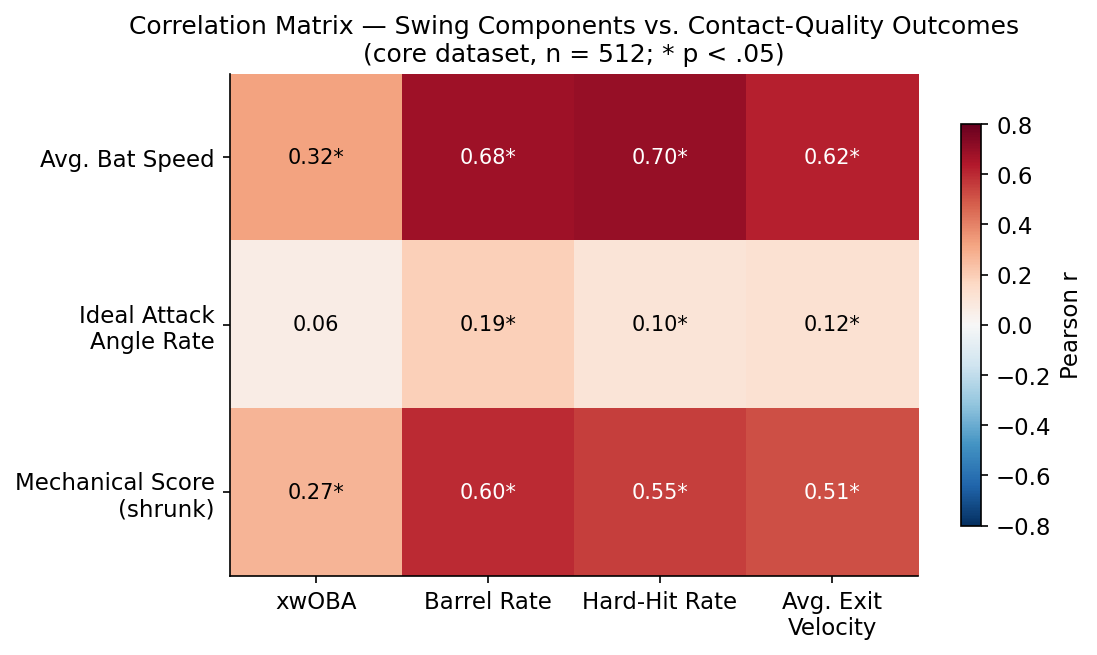

In [34]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# --- Figure 12: full correlation matrix (core dataset, n=512) ---
comp_cols = ["avg_bat_speed", "ideal_attack_angle_rate", "mechanical_swing_quality_shrunk"]
outcome_cols = ["xwoba", "barrel_rate", "hard_hit_rate", "avg_exit_velocity"]
comp_labels = ["Avg. Bat Speed", "Ideal Attack\nAngle Rate", "Mechanical Score\n(shrunk)"]
outcome_labels = ["xwOBA", "Barrel Rate", "Hard-Hit Rate", "Avg. Exit\nVelocity"]

corr_mat = np.zeros((len(comp_cols), len(outcome_cols)))
sig_mat = np.empty((len(comp_cols), len(outcome_cols)), dtype=object)

for i, c in enumerate(comp_cols):
    for j, o in enumerate(outcome_cols):
        sub = core_df[[c, o]].dropna()
        r, p = stats.pearsonr(sub[c], sub[o])
        corr_mat[i, j] = r
        sig_mat[i, j] = f"{r:.2f}" + ("*" if p < 0.05 else "")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
im = ax.imshow(corr_mat, cmap="RdBu_r", vmin=-0.8, vmax=0.8, aspect="auto")
ax.set_xticks(range(len(outcome_cols))); ax.set_xticklabels(outcome_labels)
ax.set_yticks(range(len(comp_cols))); ax.set_yticklabels(comp_labels)
for i in range(len(comp_cols)):
    for j in range(len(outcome_cols)):
        ax.text(j, i, sig_mat[i, j], ha="center", va="center",
                color="white" if abs(corr_mat[i, j]) > 0.4 else "black", fontsize=10)
ax.set_title("Correlation Matrix \u2014 Swing Components vs. Contact-Quality Outcomes\n"
             "(core dataset, n = 512; * p < .05)", fontsize=12)
cbar = fig.colorbar(im, ax=ax, shrink=0.8); cbar.set_label("Pearson r")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure_12_rq1_correlation_matrix.png", bbox_inches="tight")
plt.show()


In [35]:
mc_cols = ["xwoba", "barrel_rate", "hard_hit_rate", "avg_exit_velocity"]
print(core_df[mc_cols].corr().round(3))
print()
r_hh_ev, p_hh_ev = stats.pearsonr(*core_df[["hard_hit_rate", "avg_exit_velocity"]].dropna().values.T)


                   xwoba  barrel_rate  hard_hit_rate  avg_exit_velocity
xwoba              1.000        0.615          0.583              0.625
barrel_rate        0.615        1.000          0.742              0.708
hard_hit_rate      0.583        0.742          1.000              0.901
avg_exit_velocity  0.625        0.708          0.901              1.000



In [36]:
sub = core_df[["expanded_latent_swing_quality_shrunk", "xwoba"]].dropna()
r_circ, p_circ = stats.pearsonr(sub["expanded_latent_swing_quality_shrunk"], sub["xwoba"])
print(f"Expanded LSQ vs xwOBA: r={r_circ:.3f}, p={p_circ:.2e}")


Expanded LSQ vs xwOBA: r=0.687, p=1.03e-72


In [37]:
pairs = [("avg_bat_speed", "xwoba"), ("avg_bat_speed", "barrel_rate"),
         ("ideal_attack_angle_rate", "xwoba"), ("ideal_attack_angle_rate", "barrel_rate")]

header = "{:<45}{:<15}{:<18}{}".format("pair", "r (n=587)", "r (n=512 core)", "p (core)")
print(header)
for a, b in pairs:
    sub_full = working_df[[a, b]].dropna()
    r_full, _ = stats.pearsonr(sub_full[a], sub_full[b])
    sub_core = core_df[[a, b]].dropna()
    r_core, p_core = stats.pearsonr(sub_core[a], sub_core[b])
    sig = "*" if p_core < 0.05 else "n.s."
    label = a + " vs " + b
    print(f"{label:<45}{r_full:<15.3f}{r_core:<18.3f}{p_core:.3f} ({sig})")


pair                                         r (n=587)      r (n=512 core)    p (core)
avg_bat_speed vs xwoba                       0.272          0.323             0.000 (*)
avg_bat_speed vs barrel_rate                 0.632          0.680             0.000 (*)
ideal_attack_angle_rate vs xwoba             0.097          0.062             0.159 (n.s.)
ideal_attack_angle_rate vs barrel_rate       0.179          0.190             0.000 (*)


---
## Section H — Dashboard Data Export



In [38]:
export_df = working_df.copy()

export_df = validate_join(
    export_df, exp_2025,
    right_key_candidates=["player_id", "playerid", "mlbam_id", "batter"],
    value_cols=["est_ba", "est_slg"],
    label="expected_stats (xBA / xSLG, for dashboard)"
)
export_df = export_df.rename(columns={"est_ba": "xba", "est_slg": "xslg"})
print("xba/xslg added:", export_df[["xba", "xslg"]].notna().sum().to_dict())


[expected_stats (xBA / xSLG, for dashboard)] matched 587/587 (100.0%)
xba/xslg added: {'xba': 587, 'xslg': 587}


In [39]:
def tier_label(pctile, suffix):
    if pctile >= 90: tier = "Elite"
    elif pctile >= 70: tier = "Strong"
    elif pctile >= 50: tier = "Above-average"
    elif pctile >= 25: tier = "Below-average"
    else: tier = "Low"
    return f"{tier} reliability-adjusted {suffix} profile"

export_df["mechanical_swing_quality_shrunk_percentile"] = (
    export_df["mechanical_swing_quality_shrunk"].rank(pct=True) * 100
)
export_df["mechanical_swing_quality_adjusted_label"] = export_df[
    "mechanical_swing_quality_shrunk_percentile"
].apply(lambda p: tier_label(p, "mechanical"))

export_df["expanded_lsq_label"] = export_df[
    "expanded_latent_swing_quality_shrunk_percentile"
].apply(lambda p: tier_label(p, "expanded") if pd.notna(p) else np.nan)

export_df = export_df.rename(columns={
    "z_avg_bat_speed": "raw_swing_power_score",
    "z_ideal_attack_angle_rate": "swing_path_efficiency_score",
})


In [40]:
main_export_cols = [
    "name", "side", "avg_bat_speed", "ideal_attack_angle_rate", "competitive_swings",
    "date_start", "date_end",
    "raw_swing_power_score", "swing_path_efficiency_score",
    "mechanical_swing_quality_score", "msq_reliability", "mechanical_swing_quality_shrunk",
    "mechanical_swing_quality_shrunk_percentile", "mechanical_swing_quality_adjusted_label",
    "xwoba", "xba", "xslg", "avg_exit_velocity", "hard_hit_rate", "barrel_rate",
    "expanded_latent_swing_quality_shrunk", "expanded_latent_swing_quality_shrunk_percentile",
    "expanded_lsq_label",
]
missing_cols = [c for c in main_export_cols if c not in export_df.columns]
if missing_cols:
    print("WARNING - missing columns, check upstream sections:", missing_cols)

main_out = export_df[[c for c in main_export_cols if c in export_df.columns]]
main_out.to_csv(OUTPUT_DIR / "dashboard_ready_swing_quality_scores.csv", index=False)
print("Saved dashboard_ready_swing_quality_scores.csv", main_out.shape)

# --- Export: comp_df (composite_latent_swing_quality_scores.csv) ---
comp_export_cols = ["name", "swing_tilt", "attack_angle", "attack_direction"]
comp_out = export_df[[c for c in comp_export_cols if c in export_df.columns]]
comp_out.to_csv(OUTPUT_DIR / "composite_latent_swing_quality_scores.csv", index=False)
print("Saved composite_latent_swing_quality_scores.csv", comp_out.shape)


Saved dashboard_ready_swing_quality_scores.csv (587, 23)
Saved composite_latent_swing_quality_scores.csv (587, 4)
